<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/BigImgSingnal/Arrythmia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Arrhythmia detection

Given a set of heart signals, determine whether the patient has arrhythmia or not.

In [2]:
from google.colab import drive
import pandas as pd
import torch
from torch import nn
import numpy as np
import sklearn
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import confusion_matrix

In [3]:
# load datset
drive.flush_and_unmount()
drive.mount('/content/drive')
path="/content/drive/MyDrive/Big Img Sig/ArrhythmiaDetection/arrhythmia_dataset"

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [53]:
# Datatset reader
class Dataset(torch.utils.data.Dataset):
  def __init__(self, csv_path):
    self.df = pd.read_csv(csv_path, sep=",")
    self.input_col = self.df.columns[:-1]
    self.output_col = self.df.columns[-1]
  def __len__(self):
    return len(self.df)
  def __getitem__(self, index):
    row = self.df.iloc[index]
    input_row = row[self.input_col]
    output_row = row[self.output_col]
    feature = torch.tensor(input_row.to_numpy(), dtype=torch.float32)
    attribute = torch.tensor(output_row, dtype=torch.int)
    return feature, attribute


In [5]:
train_dataset = Dataset(f'{path}/train.csv')
test_dataset = Dataset(f'{path}/test.csv')
validate_dataset = Dataset(f'{path}/val.csv')

In [6]:
# add dataset loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=32, num_workers=2, shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=32, num_workers=2, shuffle=True)
validate_loader = torch.utils.data.DataLoader(dataset=validate_dataset, batch_size=32, num_workers=2, shuffle=True)

In [13]:
# Create the Network
class CN_Network(nn.Module):
  def __init__(self):
    super(CN_Network, self).__init__()
    # create a 1D CNN layers
    self.conv1 = nn.Conv1d(in_channels=1, out_channels=164, kernel_size=3, )
    self.relu1 = nn.ReLU()
    self.max_pool1 = nn.MaxPool1d(kernel_size=3) # reduce the number of the feature

    self.conv2 = nn.Conv1d(in_channels=164, out_channels=80, kernel_size=2)
    self.relu2 = nn.ReLU()
    self.max_pool2 = nn.MaxPool1d(kernel_size=3)

    self.conv3 = nn.Conv1d(in_channels=80, out_channels=32, kernel_size=2)
    self.relu3 = nn.ReLU()
    self.max_pool3 = nn.MaxPool1d(kernel_size=2)


    # flat the features
    self.flat1 = nn.Flatten()
    # add a linear layer
    self.linear1 = nn.Linear(in_features=288, out_features=64)
    self.relu4 = nn.ReLU()
    # add the output layer for the
    self.output_layer = nn.Linear(in_features=64, out_features=1)
    self.sigmoid_layer = nn.Sigmoid()
  def forward(self, x):
    # layer 1
    out = self.conv1(x)
    out = self.relu1(out)
    out = self.max_pool1(out)
    # layer 2
    out = self.conv2(out)
    out = self.relu2(out)
    out = self.max_pool2(out)
    # layer 3
    out = self.conv3(out)
    out = self.relu3(out)
    out = self.max_pool3(out)
    # flatten
    out = self.flat1(out)
    # linear layer
    # print(f"Out shape: {out.shape}\n Out layer: {out}")

    out = self.linear1(out)
    out = self.relu4(out)
    # output layer
    out = self.output_layer(out)
    out = self.sigmoid_layer(out)
    return out

model = CN_Network()
model

CN_Network(
  (conv1): Conv1d(1, 164, kernel_size=(3,), stride=(1,))
  (relu1): ReLU()
  (max_pool1): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(164, 80, kernel_size=(2,), stride=(1,))
  (relu2): ReLU()
  (max_pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(80, 32, kernel_size=(2,), stride=(1,))
  (relu3): ReLU()
  (max_pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flat1): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=288, out_features=64, bias=True)
  (relu4): ReLU()
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid_layer): Sigmoid()
)

In [61]:
dumy_dataset = torch.randn(1, 1, 187,)
# test the model
pred = model(dumy_dataset)

In [7]:
# define loss and optimizer function
loss_fun = nn.BCELoss()
optimizer_fun = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [8]:
# Training the model method
threshold = 0.5
def training_model(dataloader, loss_fun, optimizer_fun):
  model.train()
  number_of_batches = len(dataloader) # totale batches in the datasloader
  size = len(dataloader.dataset) # number of dataset
  training_loss, training_accuracy = 0, 0
  for batch, (X, y) in enumerate(dataloader):
    X = X.unsqueeze(1)
    y = y.unsqueeze(1).float()
    pred = model(X)

    pred_probs = torch.sigmoid(pred)
    pred_label = (pred_probs > threshold).int() # apply threshold to get the label
    loss = loss_fun(pred_probs, y)
    # Backpropagation
    optimizer_fun.zero_grad() # reset the gradient
    loss.backward() # compute the gradient
    optimizer_fun.step() # update weidths

    training_loss += loss.item()
    acc = (pred_label == y.int()).float().sum().item()
    training_accuracy += acc

    if batch % 100 == 0:
            current =(batch + 1) * len(X)
            print(f"\nloss: {loss:>7f} [{current:>5d}/{size:>5d}]")


  return training_loss/number_of_batches, training_accuracy/size

In [9]:
# Validating the model method
threshold = 0.5
def validate_model(dataloader, loss_fun):
  model.eval()
  validation_loss, validation_acc = 0,0

  with torch.no_grad(): # disables the automatic gradient calculation
    for batch, (X, y) in enumerate(dataloader):
      X, y = X.unsqueeze(1), y.unsqueeze(1).float()
      pred = model(X)
      pred_probs= torch.sigmoid(pred)
      pred_labels = (pred_probs > threshold).int()

      loss = loss_fun(pred_probs, y)
      validation_loss += loss.item()
      acc = (pred_labels == y.int()).float().sum().item()
      validation_acc  += acc
      # print(f' batch: {batch}  loss: {loss}  acc: {acc} pred_labels {pred_labels[:2]}')
  return validation_loss/len(dataloader), validation_acc/len(dataloader.dataset)

In [7]:
model_path="/content/drive/MyDrive/Big Img Sig/ArrhythmiaDetection/model"

In [ ]:
training_history = {'train-loss': [], 'train-acc': []}
validation_history = {'val-loss':[], 'val-acc': []}

for i in range(5):
  # train the models
  print(f'Epoch {i+1} ----------------------------- ')
  tr_loss, tr_acc = training_model(train_loader, loss_fun, optimizer_fun)
  training_history['train-loss'].append(tr_loss)
  training_history['train-acc'].append(tr_acc)
  # validate the model
  val_loss, val_acc = validate_model(validate_loader, loss_fun)
  validation_history['val-loss'].append(val_loss)
  validation_history['val-acc'].append(val_acc)

print("\n------------ Saving model ---------")
torch.save(model, f'{model_path}/arrythmia.pt', )

print(f"  Model Saved Successfully at:\n {model_path}/arrythmia.pt")

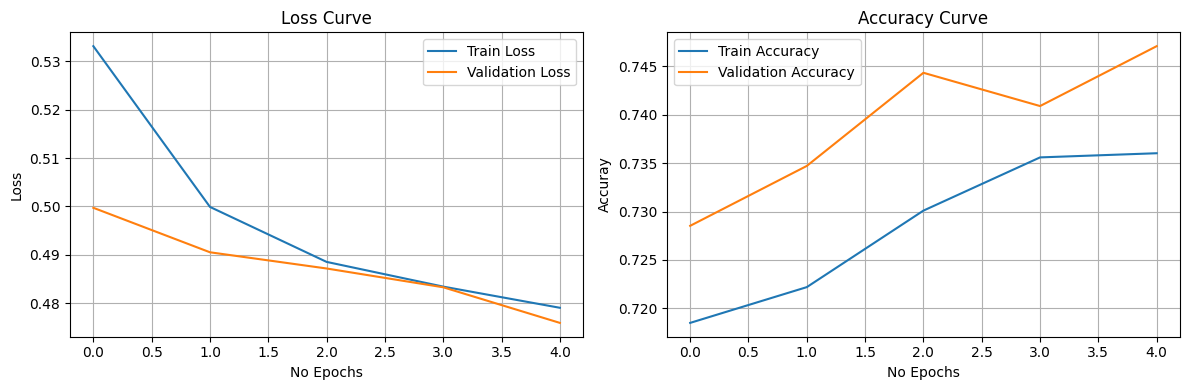

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# loss cureve
ax[0].plot(training_history['train-loss'], label='Train Loss')
ax[0].plot(validation_history['val-loss'], label='Validation Loss')
# accuracy curve
ax[1].plot(training_history['train-acc'], label='Train Accuracy')
ax[1].plot(validation_history['val-acc'], label='Validation Accuracy')

# loss curve properties
ax[0].set_xlabel("No Epochs")
ax[0].set_ylabel('Loss')
ax[0].set_title('Loss Curve')
ax[0].grid()
ax[0].legend()
# accuray curve properties
ax[1].set_xlabel("No Epochs")
ax[1].set_ylabel('Accuray')
ax[1].set_title('Accuracy Curve')
ax[1].grid()
ax[1].legend()
plt.tight_layout()

In [15]:
# load the model
loaded_model = torch.load(f'{model_path}/arrythmia.pt', weights_only=False)
# to set dropout and batch normalization layers to evaluation mode before running inference.
# Failing to do this will yield inconsistent inference results.
loaded_model.eval()


CN_Network(
  (conv1): Conv1d(1, 164, kernel_size=(3,), stride=(1,))
  (relu1): ReLU()
  (max_pool1): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(164, 80, kernel_size=(2,), stride=(1,))
  (relu2): ReLU()
  (max_pool2): MaxPool1d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(80, 32, kernel_size=(2,), stride=(1,))
  (relu3): ReLU()
  (max_pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flat1): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=288, out_features=64, bias=True)
  (relu4): ReLU()
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid_layer): Sigmoid()
)

In [54]:
# load the test dataset
testing_data = Dataset(f'{path}/test.csv')

In [55]:
testing_data.df

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,class
0,0.971286,0.641698,0.143571,0.000000,0.065543,0.141698,0.192884,0.191011,0.210362,0.212235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,0.995360,0.214617,0.000000,0.110209,0.341067,0.386311,0.494200,0.394432,0.440835,0.441995,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,1.000000,0.912195,0.822996,0.645296,0.382578,0.158885,0.073868,0.024390,0.159582,0.213240,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,1.000000,0.578536,0.152961,0.043174,0.036184,0.039885,0.021793,0.026727,0.016447,0.020559,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,1.000000,0.891645,0.630548,0.394256,0.347258,0.233681,0.182768,0.227154,0.227154,0.249347,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,1.000000,0.981721,0.792460,0.559025,0.366717,0.238385,0.129474,0.089109,0.081493,0.085301,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1452,0.962754,0.435666,0.000000,0.095937,0.306998,0.537246,0.586907,0.602709,0.601580,0.606095,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1453,0.932432,1.000000,0.879505,0.563063,0.347973,0.273649,0.181306,0.225225,0.373874,0.367117,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1454,0.961121,0.524864,0.051537,0.000452,0.000000,0.089964,0.147378,0.146022,0.153255,0.158228,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [63]:
testing_dataloader = torch.utils.data.DataLoader(testing_data, batch_size=32,shuffle=False, drop_last=False)

In [79]:
ground_truth = testing_dataloader.dataset.df[testing_dataloader.dataset.output_col]
len(ground_truth)

1456

In [80]:

def predict_model(model, dataloader):
  threshold = 0.5
  model.eval()
  probabilities = []
  predicted_label = []
  with torch.no_grad(): # disable the automatic gradient calculation
    for X,_ in dataloader:
      X = X.unsqueeze(1)
      y_pred = model(X)
      prob = torch.sigmoid(y_pred)
      probabilities.append(prob)
      pred_label = (prob > threshold).int()
      predicted_label.append(pred_label)
  return probabilities, predicted_label

In [81]:
probabilities , predicted_labels = predict_model(loaded_model, testing_dataloader)

In [ ]:
probabilities = torch.tensor(probabilities)
ground_truth = torch.tensor(ground_truth)
predicted_labels = torch.cat(predicted_labels)

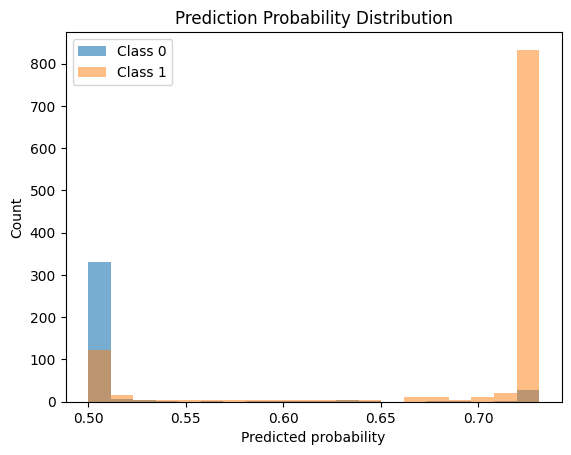

In [123]:
plt.hist(probabilities[ground_truth==0].numpy(), bins=20, alpha=0.6, label='Class 0')
plt.hist(probabilities[ground_truth==1].numpy(), bins=20, alpha=0.5, label='Class 1',)
plt.xlabel('Predicted probability')
plt.ylabel('Count')
plt.title('Prediction Probability Distribution')
plt.legend()
plt.show()

In [127]:
len(predicted_labels)

46

In [134]:
cm = confusion_matrix(ground_truth, predicted_labels)
cm

array([[  42,  343],
       [  11, 1060]])

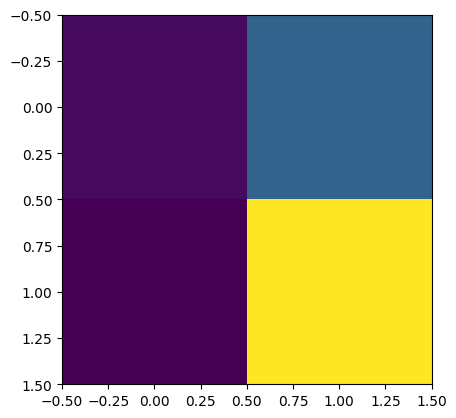

In [137]:
plt.imshow(cm)
